# ML4HD Project C2 — Bone Age Estimation (RSNA 2017)
This notebook trains and evaluates lightweight CNN models for pediatric bone age estimation from hand radiographs under *from-scratch* constraints.
We compare:
- M1: whole-image CNN
- M2: whole-image CNN + gender
- M3: patch-based CNN + mean fusion
- M4: patch-based CNN + learned fusion + gender

Outputs: trained checkpoints, result tables, and figures used in the report.


## Imports + global settings

In [ ]:
import os, glob, random, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from IPython.display import Image, display

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

AUTOTUNE = tf.data.AUTOTUNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2025-12-27 17:38:46.033020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766857126.269995      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766857126.338277      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766857126.897179      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766857126.897223      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766857126.897226      55 computation_placer.cc:177] computation placer alr

### Plot style

In [2]:
PLOT_STYLE = {
    "model_colors": {
        "M1_image_only":            "#4C72B0",
        "M2_image_gender":          "#DD8452",
        "M3_patches_mean":          "#55A868",
        "M4_patches_learned_gender":"#C44E52",
    },
    # Generic colors for non-model plots
    "train_alpha": 0.90,
    "val_alpha":   0.90,
    "val_linestyle": "--",
    "grid_alpha": 0.30,

    # Error analysis colors
    "gender_colors": {"female": "#4C72B0", "male": "#DD8452"},
    "bins_color": "#4C72B0",

    # Bar plot default if model name not in mapping
    "fallback_color": "#4C72B0",
}

def _get_model_color(model_name: str, style=PLOT_STYLE):
    return style["model_colors"].get(model_name, style["fallback_color"])

## 1) Load RSNA dataset CSVs and build image paths

In [3]:
DATA_ROOT = "/kaggle/input/rsna-pediatric-bone-age-challenge-2017"

TRAIN_CSV = os.path.join(DATA_ROOT, "Bone+Age+Training+Set+Annotations", "train.csv")
TRAIN_IMG_ROOT = os.path.join(DATA_ROOT, "Bone+Age+Training+Set", "boneage-training-dataset")

VAL_CSV = os.path.join(DATA_ROOT, "Bone+Age+Validation+Set", "Bone Age Validation Set", "Validation Dataset.csv")
VAL_IMG_ROOT = os.path.join(DATA_ROOT, "Bone+Age+Validation+Set")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

train_df = train_df.rename(columns={"id": "id", "boneage": "boneage", "male": "male"})
val_df   = val_df.rename(columns={"Image ID": "id", "Bone Age (months)": "boneage", "male": "male"})

for df in (train_df, val_df):
    df["id"] = df["id"].astype(str)
    df["boneage"] = df["boneage"].astype(np.float32)
    df["male"] = df["male"].astype(np.float32)

def build_id_map(root):
    paths = glob.glob(os.path.join(root, "**", "*.png"), recursive=True)
    return {os.path.splitext(os.path.basename(p))[0]: p for p in paths}

def attach_paths(df, id_map):
    df = df.copy()
    df["path"] = df["id"].map(id_map)
    n_missing = int(df["path"].isna().sum())
    if n_missing:
        raise FileNotFoundError(f"Missing {n_missing} images.")
    return df

train_df = attach_paths(train_df, build_id_map(TRAIN_IMG_ROOT))
val_df   = attach_paths(val_df, build_id_map(VAL_IMG_ROOT))

print("Train rows:", len(train_df), "Val rows:", len(val_df))
train_df.head()

Train rows: 12611 Val rows: 1425


,id,boneage,male,path
0,1377,180.0,0.0,/kaggle/input/rsna-pediatric-bone-age-challeng...
1,1378,12.0,0.0,/kaggle/input/rsna-pediatric-bone-age-challeng...
2,1379,94.0,0.0,/kaggle/input/rsna-pediatric-bone-age-challeng...
3,1380,120.0,1.0,/kaggle/input/rsna-pediatric-bone-age-challeng...
4,1381,82.0,0.0,/kaggle/input/rsna-pediatric-bone-age-challeng...


## Dataset statistics and age distribution
This section summarizes the dataset and visualizes age imbalance across predefined bins.


=== Dataset size ===
Train: 12611
Val:   1425

=== Gender distribution ===
Train: male 6833 (54.18%), female 5778 (45.82%)
Val:   male 773 (54.25%), female 652 (45.75%)

=== Bone age stats (months) ===
Train: {'n': 12611, 'mean': 127.32, 'std': 41.18, 'median': 132.0, 'min': 1.0, 'max': 228.0}
Val:   {'n': 1425, 'mean': 127.16, 'std': 41.72, 'median': 132.0, 'min': 3.0, 'max': 228.0} 

=== Age-bin counts ===
Train bins: {'0-24': 168, '24-60': 911, '60-120': 4201, '120-180': 6650, '180-216': 681}
Val bins:   {'0-24': 24, '24-60': 101, '60-120': 477, '120-180': 740, '180-216': 83}


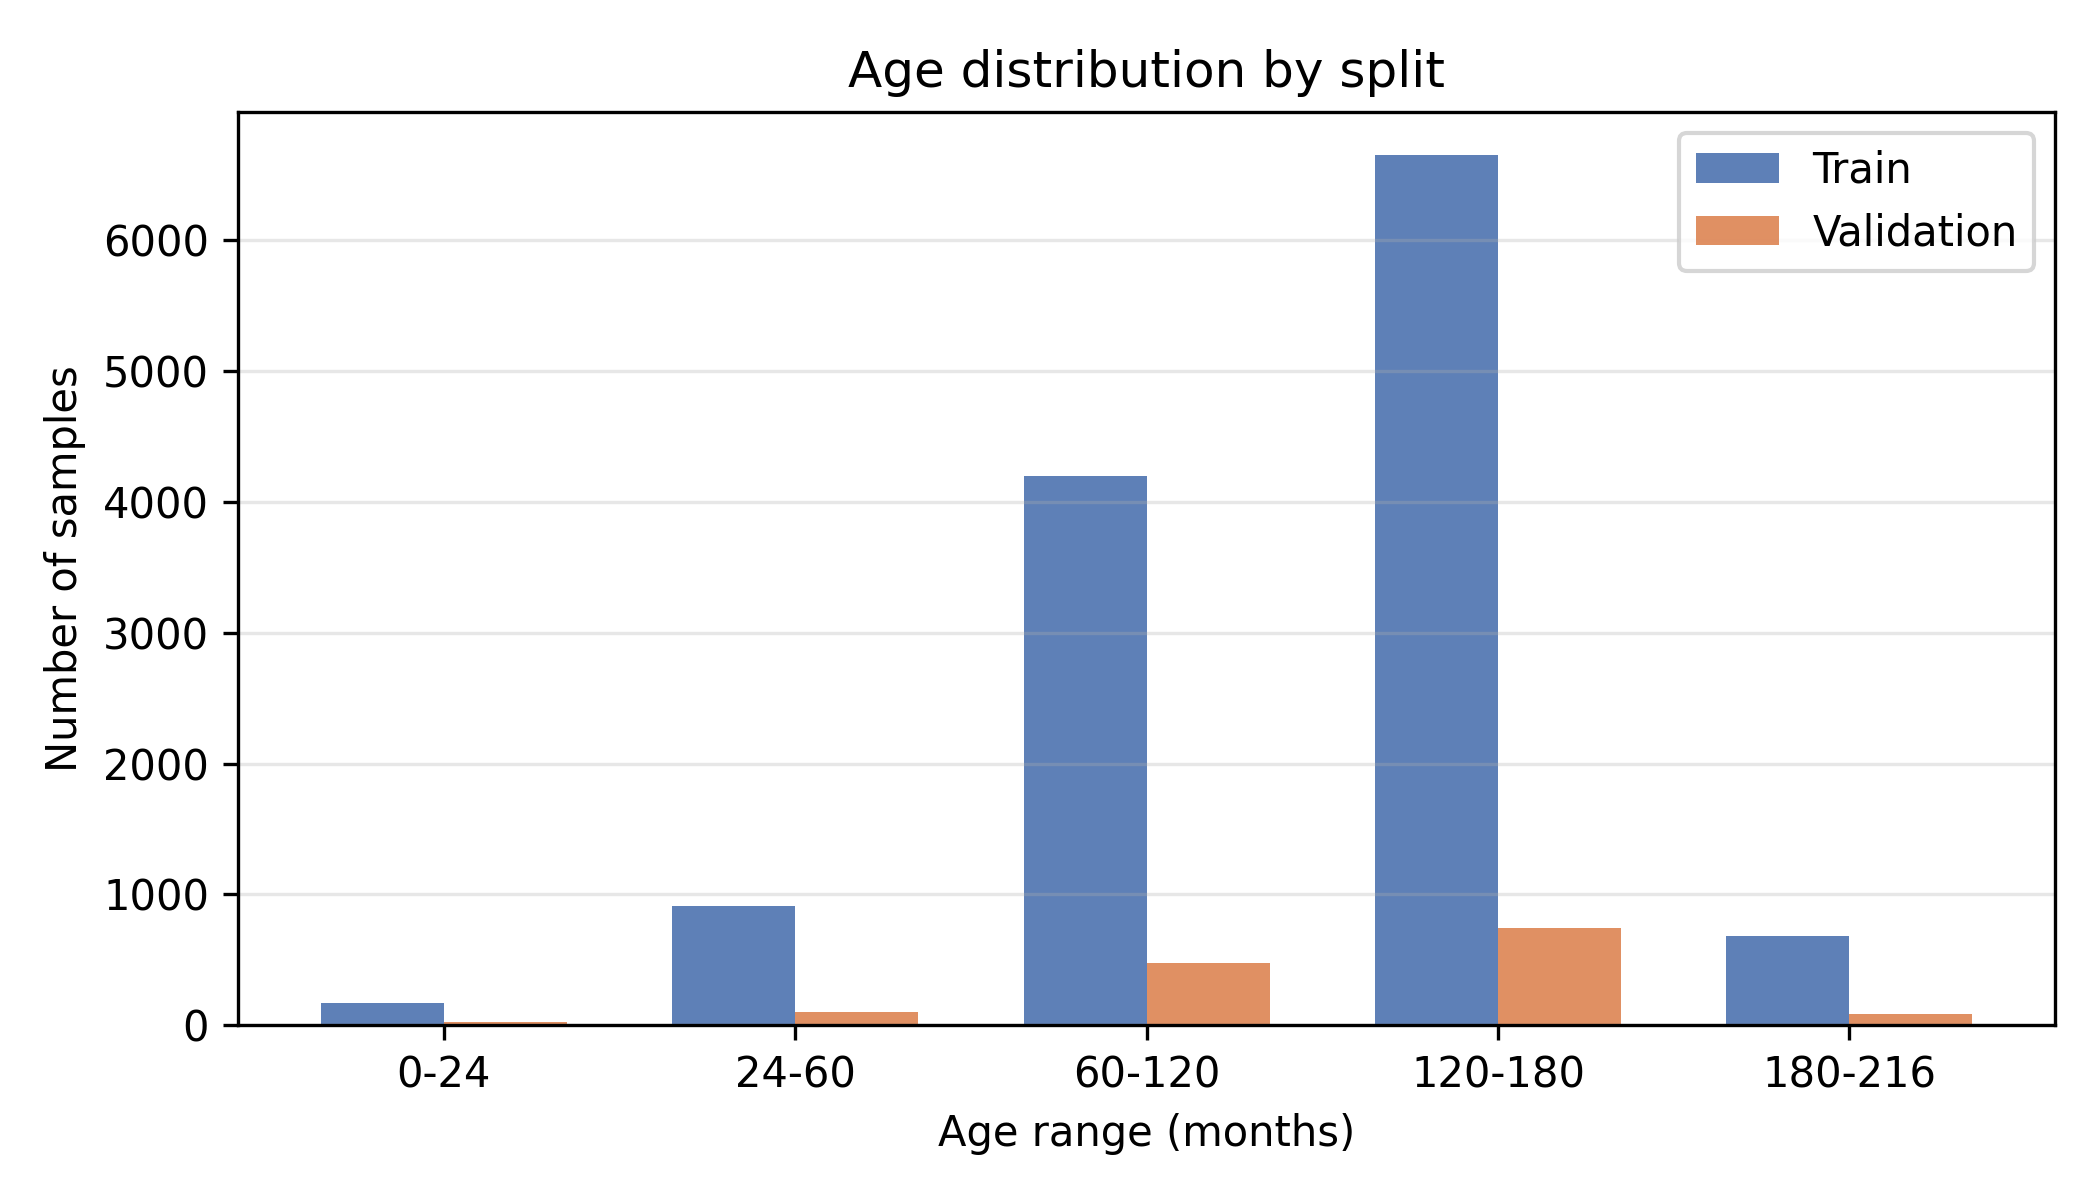

Saved: /kaggle/working/age_distribution.png


In [ ]:
def show_saved(path):
    assert os.path.exists(path), f"File not found: {path}"
    display(Image(filename=path))
    print("Saved:", path)

def describe_boneage(df: pd.DataFrame):
    y = df["boneage"].astype(float).values
    return {
        "n": int(len(y)),
        "mean": float(np.mean(y)),
        "std": float(np.std(y, ddof=1)),
        "median": float(np.median(y)),
        "min": float(np.min(y)),
        "max": float(np.max(y)),
    }

def gender_counts(df: pd.DataFrame):
    g = df["male"].astype(int).values
    n_male = int(np.sum(g == 1))
    n_female = int(np.sum(g == 0))
    n = int(len(g))
    return {
        "n": n,
        "male_count": n_male,
        "female_count": n_female,
        "male_pct": 100.0 * n_male / n if n else np.nan,
        "female_pct": 100.0 * n_female / n if n else np.nan,
    }

BINS = [0, 24, 60, 120, 180, 216]
LABELS = ["0-24", "24-60", "60-120", "120-180", "180-216"]

def age_bin_counts(df: pd.DataFrame, bins=BINS, labels=LABELS):
    y = df["boneage"].astype(float).values
    y = np.clip(y, bins[0], bins[-1])
    idx = np.digitize(y, bins, right=True) - 1
    return {lab: int(np.sum(idx == i)) for i, lab in enumerate(labels)}

# ---- Compute + print ----
train_gender = gender_counts(train_df)
val_gender   = gender_counts(val_df)
train_age = describe_boneage(train_df)
val_age   = describe_boneage(val_df)

train_bins = age_bin_counts(train_df)
val_bins   = age_bin_counts(val_df)

print("=== Dataset size ===")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}\n")

print("=== Gender distribution ===")
print(f"Train: male {train_gender['male_count']} ({train_gender['male_pct']:.2f}%), "
      f"female {train_gender['female_count']} ({train_gender['female_pct']:.2f}%)")
print(f"Val:   male {val_gender['male_count']} ({val_gender['male_pct']:.2f}%), "
      f"female {val_gender['female_count']} ({val_gender['female_pct']:.2f}%)\n")

print("=== Bone age stats (months) ===")
print("Train:", {k: (round(v, 2) if isinstance(v, float) else v) for k, v in train_age.items()})
print("Val:  ", {k: (round(v, 2) if isinstance(v, float) else v) for k, v in val_age.items()}, "\n")

print("=== Age-bin counts ===")
print("Train bins:", train_bins)
print("Val bins:  ", val_bins)

# ---- Age distribution plot ----
bins = list(train_bins.keys())
train_counts = [train_bins[b] for b in bins]
val_counts   = [val_bins[b] for b in bins]

x = np.arange(len(bins))
width = 0.35

age_dist_path = "/kaggle/working/age_distribution.png"
plt.figure(figsize=(7,4))

# Use two colors from your style: M1 and M2 as general-purpose split colors
c_train = PLOT_STYLE["model_colors"].get("M1_image_only", "tab:blue")
c_val   = PLOT_STYLE["model_colors"].get("M2_image_gender", "tab:orange")

plt.bar(x - width/2, train_counts, width, label="Train", color=c_train, alpha=0.9)
plt.bar(x + width/2, val_counts,   width, label="Validation", color=c_val, alpha=0.9)

plt.xticks(x, bins)
plt.ylabel("Number of samples")
plt.xlabel("Age range (months)")
plt.title("Age distribution by split")
plt.legend()
plt.grid(axis="y", alpha=PLOT_STYLE["grid_alpha"])
plt.tight_layout()
plt.savefig(age_dist_path, dpi=300)
plt.close()

show_saved(age_dist_path)


## 2) Target standardization (train statistics only)

In [5]:
y_mean = float(train_df["boneage"].mean())
y_std  = float(train_df["boneage"].std() + 1e-8)

train_df["y_std"] = (train_df["boneage"] - y_mean) / y_std
val_df["y_std"]   = (val_df["boneage"] - y_mean) / y_std

print("Target mean/std:", y_mean, y_std)

Target mean/std: 127.32075500488281 41.18158722923828


## 3) Compute pixel mean/std on training images (for normalization)
#### Image decoding + pixel stats

In [6]:
IMG_SIZE = 256

def decode_png(path, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [img_size, img_size])
    return tf.cast(img, tf.float32)

def estimate_pixel_stats(df, n=1024):
    sample = df.sample(min(n, len(df)), random_state=SEED)
    ds = tf.data.Dataset.from_tensor_slices(sample["path"].values)
    ds = ds.map(lambda p: decode_png(p, IMG_SIZE), num_parallel_calls=AUTOTUNE).batch(8)

    s, s2, c = 0.0, 0.0, 0
    for b in ds:
        x = tf.reshape(b, [-1]).numpy()
        s += x.sum()
        s2 += (x * x).sum()
        c += x.size
    mean = s / c
    var = s2 / c - mean**2
    std = float(np.sqrt(max(var, 1e-8)))
    return float(mean), float(std)

x_mean, x_std = estimate_pixel_stats(train_df, n=1024)
print("Pixel mean/std:", x_mean, x_std)


I0000 00:00:1766857186.605066      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766857186.605746      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Pixel mean/std: 46.04576873779297 49.63308334350586


## 4) Model configurations (M1–M4)
#### Config dataclass

In [7]:
@dataclass
class ExperimentConfig:
    name: str
    use_gender: bool
    use_patches: bool
    fusion_type: str  # "none", "mean", "learned"
    img_size: int = 256
    patch_size: int = 128
    patch_stride: int = 64
    batch_size: int = 32
    epochs: int = 20
    lr: float = 1e-3
    ckpt_path: str = ""

CONFIGS = {
    "M1": ExperimentConfig("M1_image_only", False, False, "none", ckpt_path="/kaggle/working/m1_best.keras"),
    "M2": ExperimentConfig("M2_image_gender", True,  False, "none", ckpt_path="/kaggle/working/m2_best.keras"),
    "M3": ExperimentConfig("M3_patches_mean", False, True,  "mean", ckpt_path="/kaggle/working/m3_best.keras"),
    "M4": ExperimentConfig("M4_patches_learned_gender", True, True, "learned", ckpt_path="/kaggle/working/m4_best.keras"),
}

## 5) TensorFlow input pipeline (whole image vs patches)
#### Patch extraction + tf.data

In [8]:
def num_patches(cfg: ExperimentConfig) -> int:
    return ((cfg.img_size - cfg.patch_size)//cfg.patch_stride + 1) ** 2

def extract_patches(img, patch_size, stride):
    img4 = tf.expand_dims(img, 0)
    patches = tf.image.extract_patches(
        images=img4,
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1],
        padding="VALID"
    )
    nH = tf.shape(patches)[1]
    nW = tf.shape(patches)[2]
    P = nH * nW
    return tf.reshape(patches, [P, patch_size, patch_size, 1])

def make_preprocess_fn(cfg: ExperimentConfig):
    P = num_patches(cfg)

    @tf.function
    def preprocess(path, gender, y_std_val):
        img = decode_png(path, cfg.img_size)
        img = (img - x_mean) / x_std

        if cfg.use_patches:
            patches = extract_patches(img, cfg.patch_size, cfg.patch_stride)
            patches = tf.ensure_shape(patches, [P, cfg.patch_size, cfg.patch_size, 1])
            x = {"patches": patches}
        else:
            x = {"img": img}

        if cfg.use_gender:
            x["gender"] = tf.reshape(gender, [1])

        return x, tf.reshape(y_std_val, [1])
    return preprocess

def make_dataset(df, cfg: ExperimentConfig, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["male"].values, df["y_std"].values))
    if training:
        ds = ds.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(make_preprocess_fn(cfg), num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    ds = ds.batch(cfg.batch_size).prefetch(AUTOTUNE)
    return ds


## 6) Metric and model definitions (encoder + fusion)
#### Metric + model builders


In [9]:
class MAEMonths(tf.keras.metrics.Metric):
    def __init__(self, y_mean, y_std, name="mae_months", **kw):
        super().__init__(name=name, **kw)
        self.y_mean = tf.constant(y_mean, tf.float32)
        self.y_std  = tf.constant(y_std, tf.float32)
        self.mae = tf.keras.metrics.MeanAbsoluteError()

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        yt = y_true*self.y_std + self.y_mean
        yp = y_pred*self.y_std + self.y_mean
        self.mae.update_state(yt, yp)

    def result(self):
        return self.mae.result()

    def reset_states(self):
        self.mae.reset_states()

def build_cnn_encoder(input_shape):
    inp = tf.keras.Input(shape=input_shape)
    x = inp
    for f in [32, 64, 128, 256]:
        x = tf.keras.layers.Conv2D(f, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    return tf.keras.Model(inp, x, name="cnn_encoder")

def build_model(cfg: ExperimentConfig):
    if not cfg.use_patches:
        img_in = tf.keras.Input(shape=(cfg.img_size, cfg.img_size, 1), name="img")
        enc = build_cnn_encoder((cfg.img_size, cfg.img_size, 1))
        x = enc(img_in)

        inputs = {"img": img_in}
        if cfg.use_gender:
            g_in = tf.keras.Input(shape=(1,), name="gender")
            inputs["gender"] = g_in
            x = tf.keras.layers.Concatenate()([x, g_in])

        x = tf.keras.layers.Dense(128, activation="relu")(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        out = tf.keras.layers.Dense(1, dtype="float32", name="y_std")(x)
        return tf.keras.Model(inputs=inputs, outputs=out, name=cfg.name)

    P = num_patches(cfg)
    patches_in = tf.keras.Input(shape=(P, cfg.patch_size, cfg.patch_size, 1), name="patches")
    enc = build_cnn_encoder((cfg.patch_size, cfg.patch_size, 1))
    feats = tf.keras.layers.TimeDistributed(enc, name="td_encoder")(patches_in)  # [B,P,128]

    if cfg.fusion_type == "mean":
        x = tf.keras.layers.GlobalAveragePooling1D(name="mean_fusion")(feats)
    elif cfg.fusion_type == "learned":
        scores  = tf.keras.layers.Dense(1, name="attn_score")(feats)
        weights = tf.keras.layers.Softmax(axis=1, name="attn_softmax")(scores)
        x = tf.keras.layers.Dot(axes=1, name="attn_weighted_sum")([weights, feats])
        x = tf.keras.layers.Flatten(name="attn_flatten")(x)
    else:
        raise ValueError("fusion_type must be 'mean' or 'learned'")

    inputs = {"patches": patches_in}
    if cfg.use_gender:
        g_in = tf.keras.Input(shape=(1,), name="gender")
        inputs["gender"] = g_in
        x = tf.keras.layers.Concatenate()([x, g_in])

    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    out = tf.keras.layers.Dense(1, dtype="float32", name="y_std")(x)
    return tf.keras.Model(inputs=inputs, outputs=out, name=cfg.name)


## 7) Training, evaluation, timing utilities
#### Utilities + training runner

In [10]:
def predict_mae_months(model, val_ds, val_df):
    y_pred_std = model.predict(val_ds, verbose=0).reshape(-1).astype(np.float32)
    y_pred = y_pred_std * y_std + y_mean
    y_true = val_df["boneage"].values.astype(np.float32)
    mae = float(np.mean(np.abs(y_pred - y_true)))
    return mae, y_pred, y_true

def measure_inference_time_ms(model, sample_batch, n_warmup=10, n_runs=50):
    for _ in range(n_warmup):
        _ = model(sample_batch, training=False)
    t0 = time.time()
    for _ in range(n_runs):
        _ = model(sample_batch, training=False)
    t1 = time.time()
    bs = list(sample_batch.values())[0].shape[0]
    return float(((t1 - t0) / n_runs) * 1000.0 / bs)

def plot_learning_curves(histories, out_path="/kaggle/working/learning_curves.png", style=PLOT_STYLE):
    """
    histories: dict {model_name: keras History}
    """
    plt.figure(figsize=(10, 6))
    for name, hist in histories.items():
        if hist is None:
            continue
        h = hist.history
        if "mae_months" not in h or "val_mae_months" not in h:
            continue

        c = _get_model_color(name, style)
        plt.plot(h["mae_months"], label=f"{name} train", color=c, alpha=style["train_alpha"])
        plt.plot(h["val_mae_months"], label=f"{name} val", color=c,
                 linestyle=style["val_linestyle"], alpha=style["val_alpha"])

    plt.xlabel("Epoch")
    plt.ylabel("MAE (months)")
    plt.title("Training/Validation MAE Curves")
    plt.legend()
    plt.grid(True, alpha=style["grid_alpha"])
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()
    print("Saved:", out_path)

def plot_model_bar(results_df, out_path="/kaggle/working/model_mae_bar.png", style=PLOT_STYLE):
    """
    results_df: DataFrame with columns:
      - model (string)   e.g., "M4_patches_learned_gender"
      - val_mae_months (float)
    """
    plt.figure(figsize=(8, 5))

    models = results_df["model"].tolist()
    maes   = results_df["val_mae_months"].tolist()
    colors = [_get_model_color(m, style) for m in models]

    plt.bar(models, maes, color=colors)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Best Validation MAE (months)")
    plt.title("Model Comparison (Validation MAE)")
    plt.grid(True, axis="y", alpha=style["grid_alpha"])
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()
    print("Saved:", out_path)

def error_analysis_plots(y_true, y_pred, genders, out_prefix="/kaggle/working/m2", style=PLOT_STYLE):
    """
    y_true, y_pred: arrays in months
    genders: 0/1 (0=female, 1=male)
    """
    abs_err = np.abs(y_pred - y_true)

    male_mask = genders.astype(np.int32) == 1
    female_mask = ~male_mask

    mae_male = float(abs_err[male_mask].mean()) if male_mask.any() else np.nan
    mae_female = float(abs_err[female_mask].mean()) if female_mask.any() else np.nan

    # --- MAE by Gender ---
    plt.figure(figsize=(5, 4))
    plt.bar(
        ["female", "male"],
        [mae_female, mae_male],
        color=[style["gender_colors"]["female"], style["gender_colors"]["male"]],
    )
    plt.ylabel("MAE (months)")
    plt.title("MAE by Gender")
    plt.grid(True, axis="y", alpha=style["grid_alpha"])
    plt.tight_layout()
    p1 = f"{out_prefix}_mae_by_gender.png"
    plt.savefig(p1, dpi=200)
    plt.close()
    print("Saved:", p1)

    # --- MAE by Age Bin ---
    bins = [0, 24, 60, 120, 180, 216]
    labels = ["0-24", "24-60", "60-120", "120-180", "180-216"]
    idx = np.digitize(y_true, bins, right=True) - 1

    maes = []
    for i in range(len(labels)):
        m = idx == i
        maes.append(float(abs_err[m].mean()) if m.any() else np.nan)

    plt.figure(figsize=(7, 4))
    plt.bar(labels, maes, color=style["bins_color"])
    plt.ylabel("MAE (months)")
    plt.title("MAE by Age Bin")
    plt.grid(True, axis="y", alpha=style["grid_alpha"])
    plt.tight_layout()
    p2 = f"{out_prefix}_mae_by_age_bins.png"
    plt.savefig(p2, dpi=200)
    plt.close()
    print("Saved:", p2)

    return {"mae_female": mae_female, "mae_male": mae_male, "mae_bins": maes, "bin_labels": labels}

def run_experiment(cfg: ExperimentConfig):
    print(f"\n=== Running {cfg.name} ===")
    train_ds = make_dataset(train_df, cfg, training=True)
    val_ds   = make_dataset(val_df, cfg, training=False)

    model = build_model(cfg)
    opt = tf.keras.optimizers.Adam(learning_rate=cfg.lr, clipnorm=1.0)

    model.compile(
        optimizer=opt,
        loss=tf.keras.losses.Huber(),
        metrics=[MAEMonths(y_mean, y_std)]
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(cfg.ckpt_path, monitor="val_mae_months", mode="min", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae_months", mode="min", factor=0.5, patience=3, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor="val_mae_months", mode="min", patience=6, restore_best_weights=True, verbose=1),
    ]

    history = model.fit(train_ds, validation_data=val_ds, epochs=cfg.epochs, callbacks=callbacks, verbose=1)

    best = tf.keras.models.load_model(cfg.ckpt_path, compile=False)
    mae, y_pred, y_true = predict_mae_months(best, val_ds, val_df)

    params = int(best.count_params())
    x_batch = next(iter(val_ds))[0]
    ms_per_img = measure_inference_time_ms(best, x_batch)

    print(f"{cfg.name} | BEST Val MAE: {mae:.2f} months | params={params:,} | ms/img={ms_per_img:.3f}")

    return {
        "name": cfg.name,
        "val_mae_months": mae,
        "params": params,
        "ms_per_img": ms_per_img,
        "history": history,
        "y_pred": y_pred,
        "y_true": y_true,
    }


## 8) Train and evaluate models (M1–M4)
#### Run M1–M4 and save summary

In [11]:
results = {}
for key in ["M1", "M2", "M3", "M4"]:
    results[key] = run_experiment(CONFIGS[key])

histories = {results[k]["name"]: results[k]["history"] for k in results}

summary_rows = []
for k in ["M1","M2","M3","M4"]:
    r = results[k]
    summary_rows.append({
        "model": r["name"],
        "val_mae_months": r["val_mae_months"],
        "params": r["params"],
        "ms_per_img": r["ms_per_img"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("val_mae_months")
print(summary_df)

summary_csv = "/kaggle/working/summary_results.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)



=== Running M1_image_only ===
Epoch 1/20


I0000 00:00:1766857206.921930     126 service.cc:152] XLA service 0x7a452800ad60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766857206.921972     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766857206.921977     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766857208.199617     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
2025-12-27 17:40:18.273882: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv %cudnn-conv-bw-filter.6 = (f16[128,3,3,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,64,64,64]{3,2,1,0} %bitcast.13583, f16[32,64,64,128]{3,2,1,0} %bitcast.13585), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/M1_image_only_1/cnn_encoder_1/conv2d_2_1/convolution/Conv

  2/395 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - loss: 0.7711 - mae_months: 50.3281   

I0000 00:00:1766857226.908273     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


395/395 ━━━━━━━━━━━━━━━━━━━━ 208s 466ms/step - loss: 0.4555 - mae_months: 34.3569 - val_loss: 0.4474 - val_mae_months: 34.0889 - learning_rate: 0.0010
Epoch 2/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 0.4052 - mae_months: 31.7257 - val_loss: 0.4545 - val_mae_months: 33.7637 - learning_rate: 0.0010
Epoch 3/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 0.3728 - mae_months: 29.9426 - val_loss: 1.2071 - val_mae_months: 69.2572 - learning_rate: 0.0010
Epoch 4/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 0.3367 - mae_months: 28.0534 - val_loss: 0.8538 - val_mae_months: 53.9949 - learning_rate: 0.0010
Epoch 5/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - loss: 0.3070 - mae_months: 26.4472 - val_loss: 0.2074 - val_mae_months: 20.9997 - learning_rate: 0.0010
Epoch 6/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 0.2739 - mae_months: 24.6495 - val_loss: 0.4050 - val_mae_months: 32.5522 - learning_rate: 0.0010
Epoch 7/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/

# Report Figures
This section produces all plots used in the LaTeX report.


## Learning curves (train vs validation MAE)


Saved: /kaggle/working/learning_curves.png


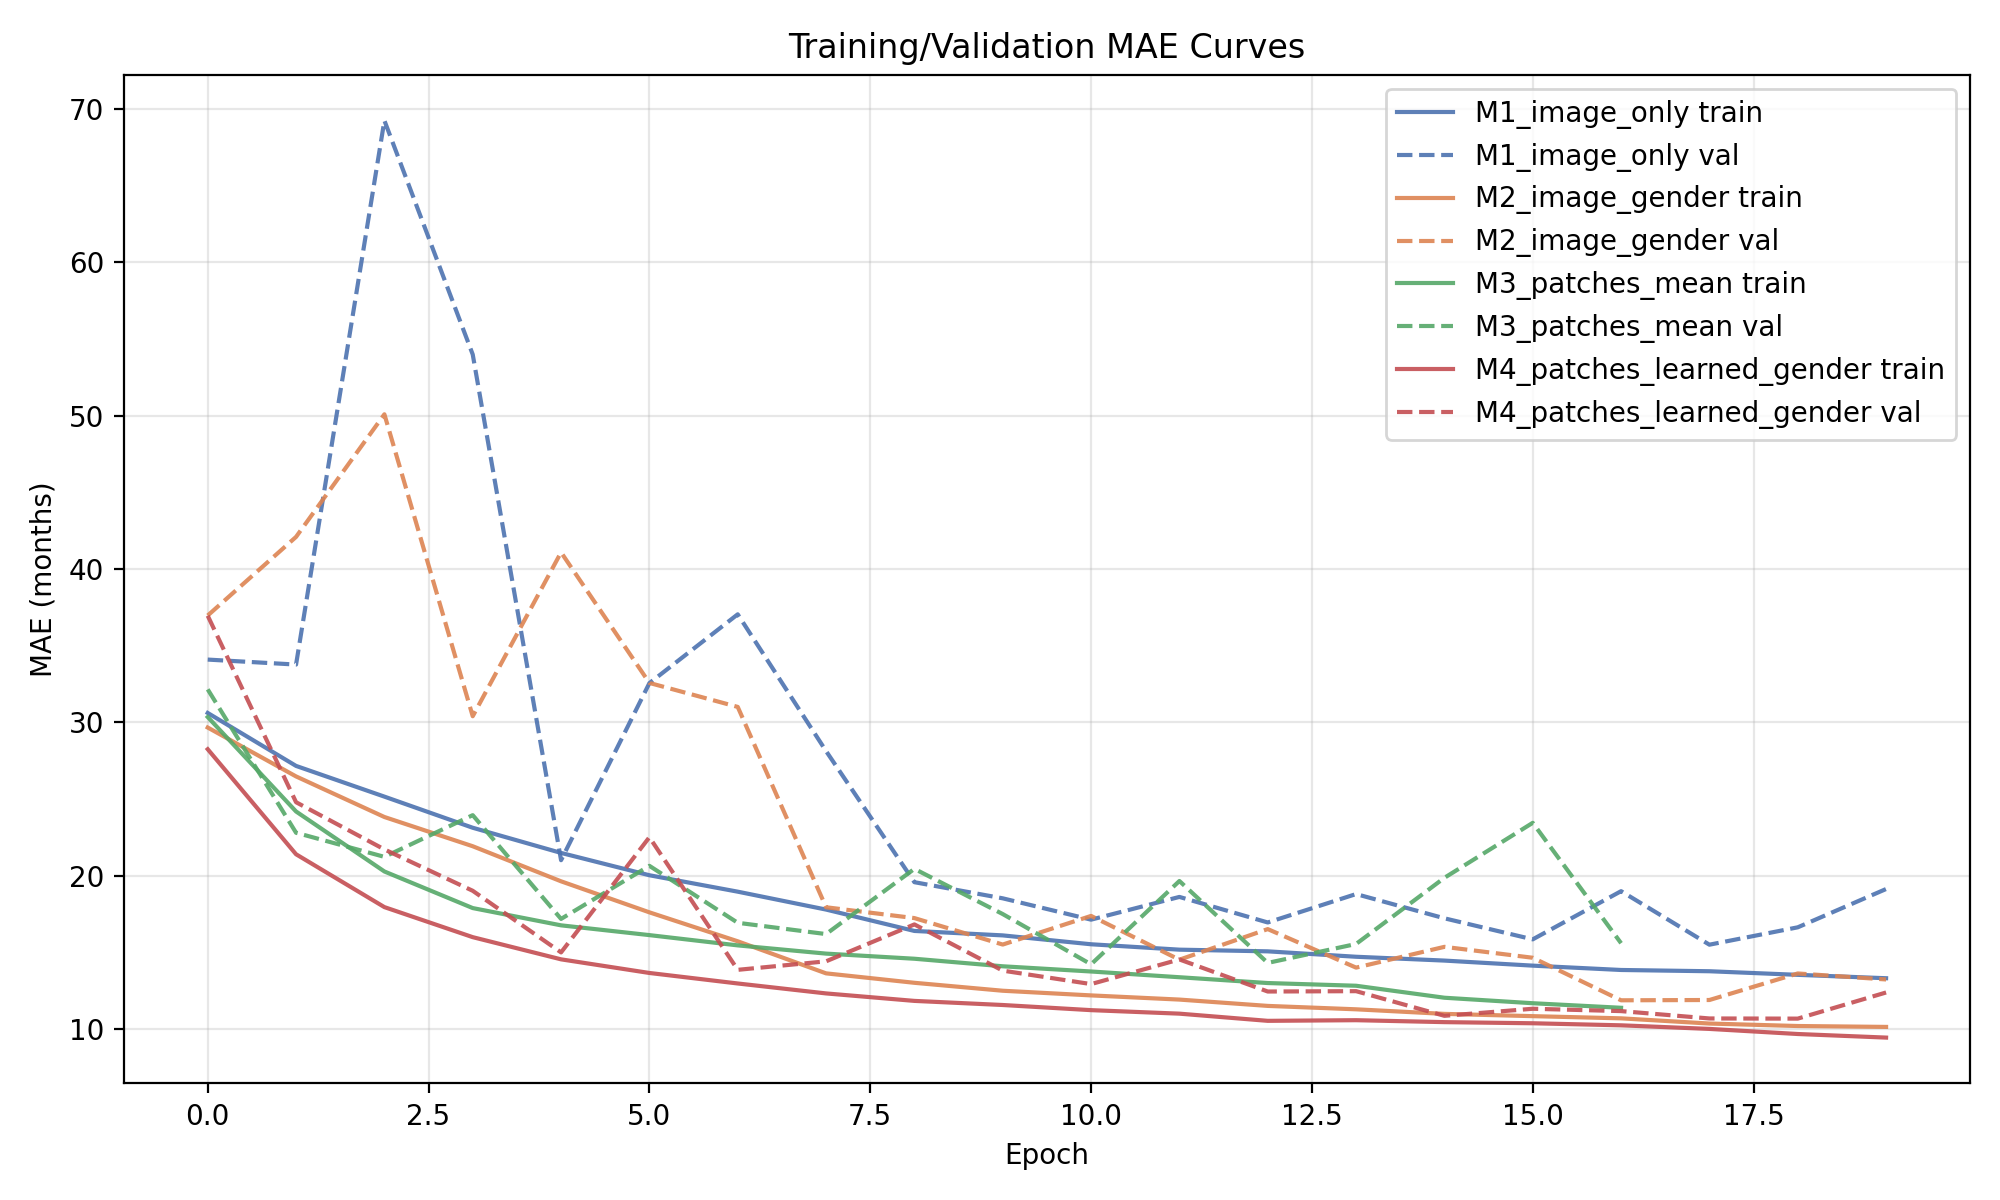

Saved: /kaggle/working/learning_curves.png


In [12]:
lc_path = "/kaggle/working/learning_curves.png"
plot_learning_curves(histories, out_path=lc_path, style=PLOT_STYLE)
show_saved(lc_path)

## Model comparison (Validation MAE)


Saved: /kaggle/working/model_mae_bar.png


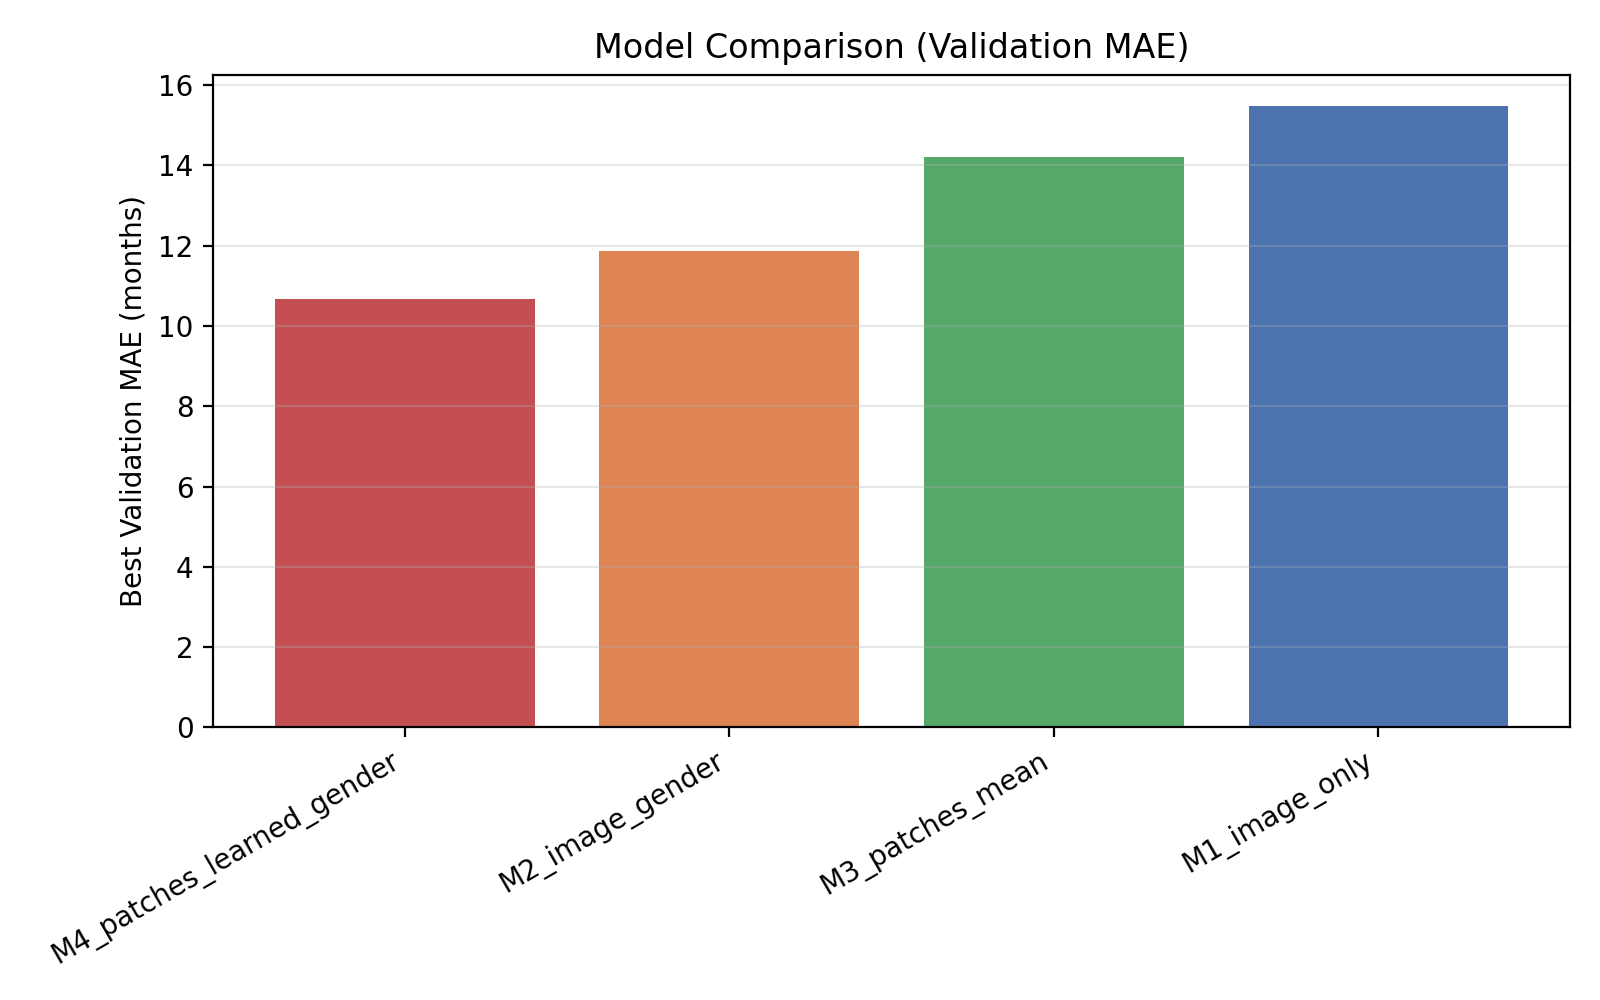

Saved: /kaggle/working/model_mae_bar.png
Summary table (sorted by validation MAE):


,model,val_mae_months,params,ms_per_img
0,M4_patches_learned_gender,10.664845,439554,5.463645
1,M2_image_gender,11.860551,439425,0.681553
2,M3_patches_mean,14.206984,439297,5.382736
3,M1_image_only,15.488350,439297,0.662886


In [13]:
bar_path = "/kaggle/working/model_mae_bar.png"
plot_model_bar(summary_df, out_path=bar_path, style=PLOT_STYLE)
show_saved(bar_path)

print("Summary table (sorted by validation MAE):")
display(summary_df.reset_index(drop=True))

## Error analysis (M2): MAE by gender and age bins

Saved: /kaggle/working/m2_mae_by_gender.png
Saved: /kaggle/working/m2_mae_by_age_bins.png


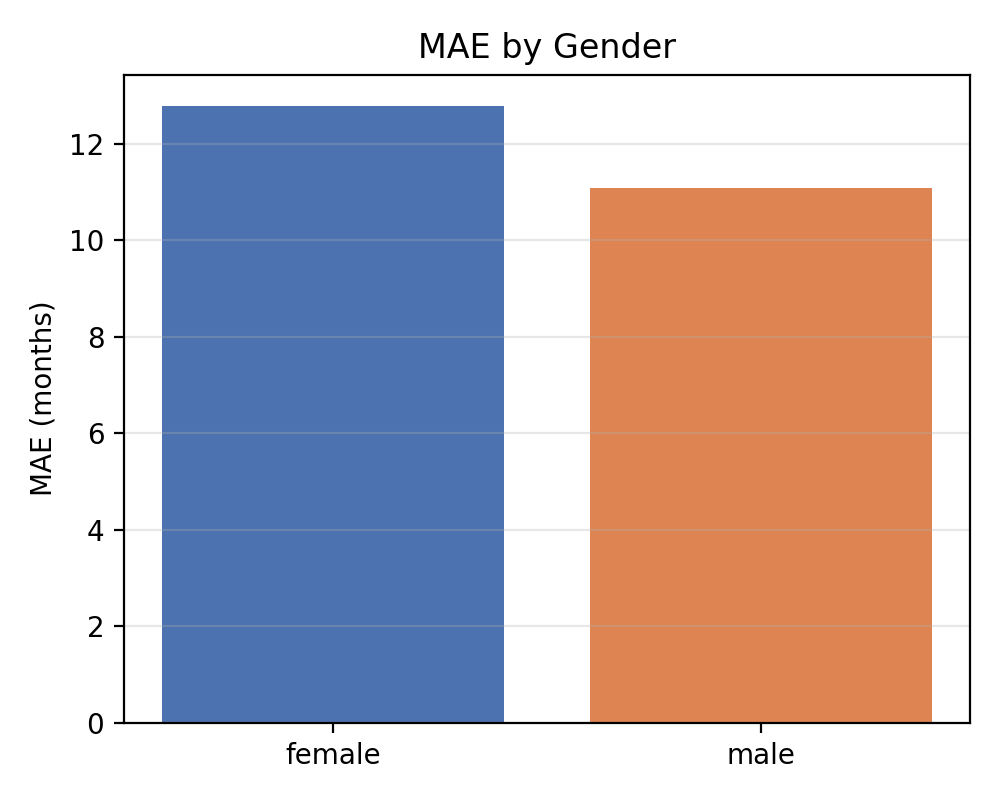

Saved: /kaggle/working/m2_mae_by_gender.png


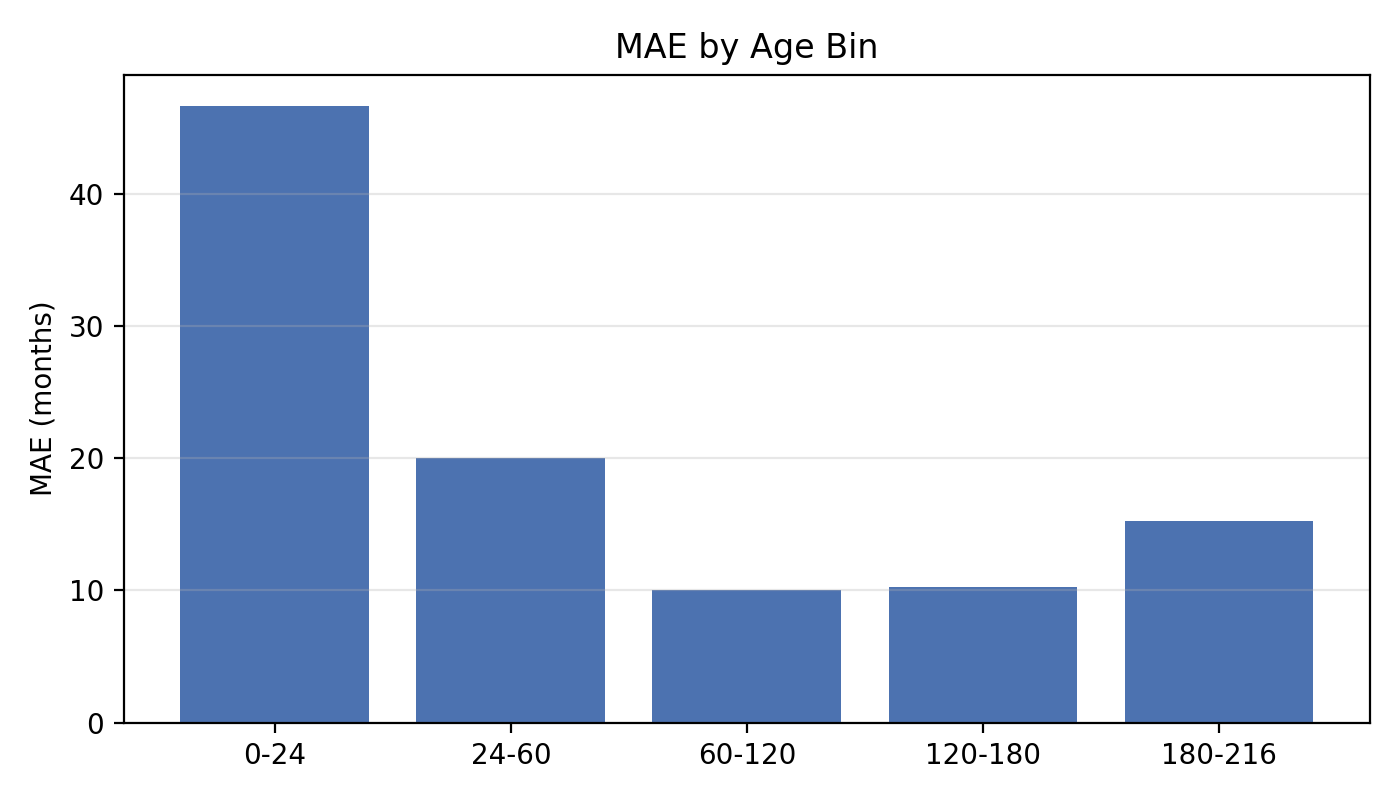

Saved: /kaggle/working/m2_mae_by_age_bins.png
M2 error analysis summary:
{'mae_female': 12.79119873046875, 'mae_male': 11.075583457946777, 'mae_bins': [46.691375732421875, 20.049030303955078, 9.999787330627441, 10.281907081604004, 15.266419410705566], 'bin_labels': ['0-24', '24-60', '60-120', '120-180', '180-216']}


In [14]:
m2 = results["M2"]
ea = error_analysis_plots(
    y_true=m2["y_true"],
    y_pred=m2["y_pred"],
    genders=val_df["male"].values.astype(np.float32),
    out_prefix="/kaggle/working/m2",
    style=PLOT_STYLE
)

show_saved("/kaggle/working/m2_mae_by_gender.png")
show_saved("/kaggle/working/m2_mae_by_age_bins.png")

print("M2 error analysis summary:")
print(ea)

## Qualitative examples (M4 by default)
#### Best / random / worst validation cases with GT, prediction, absolute error, and gender.

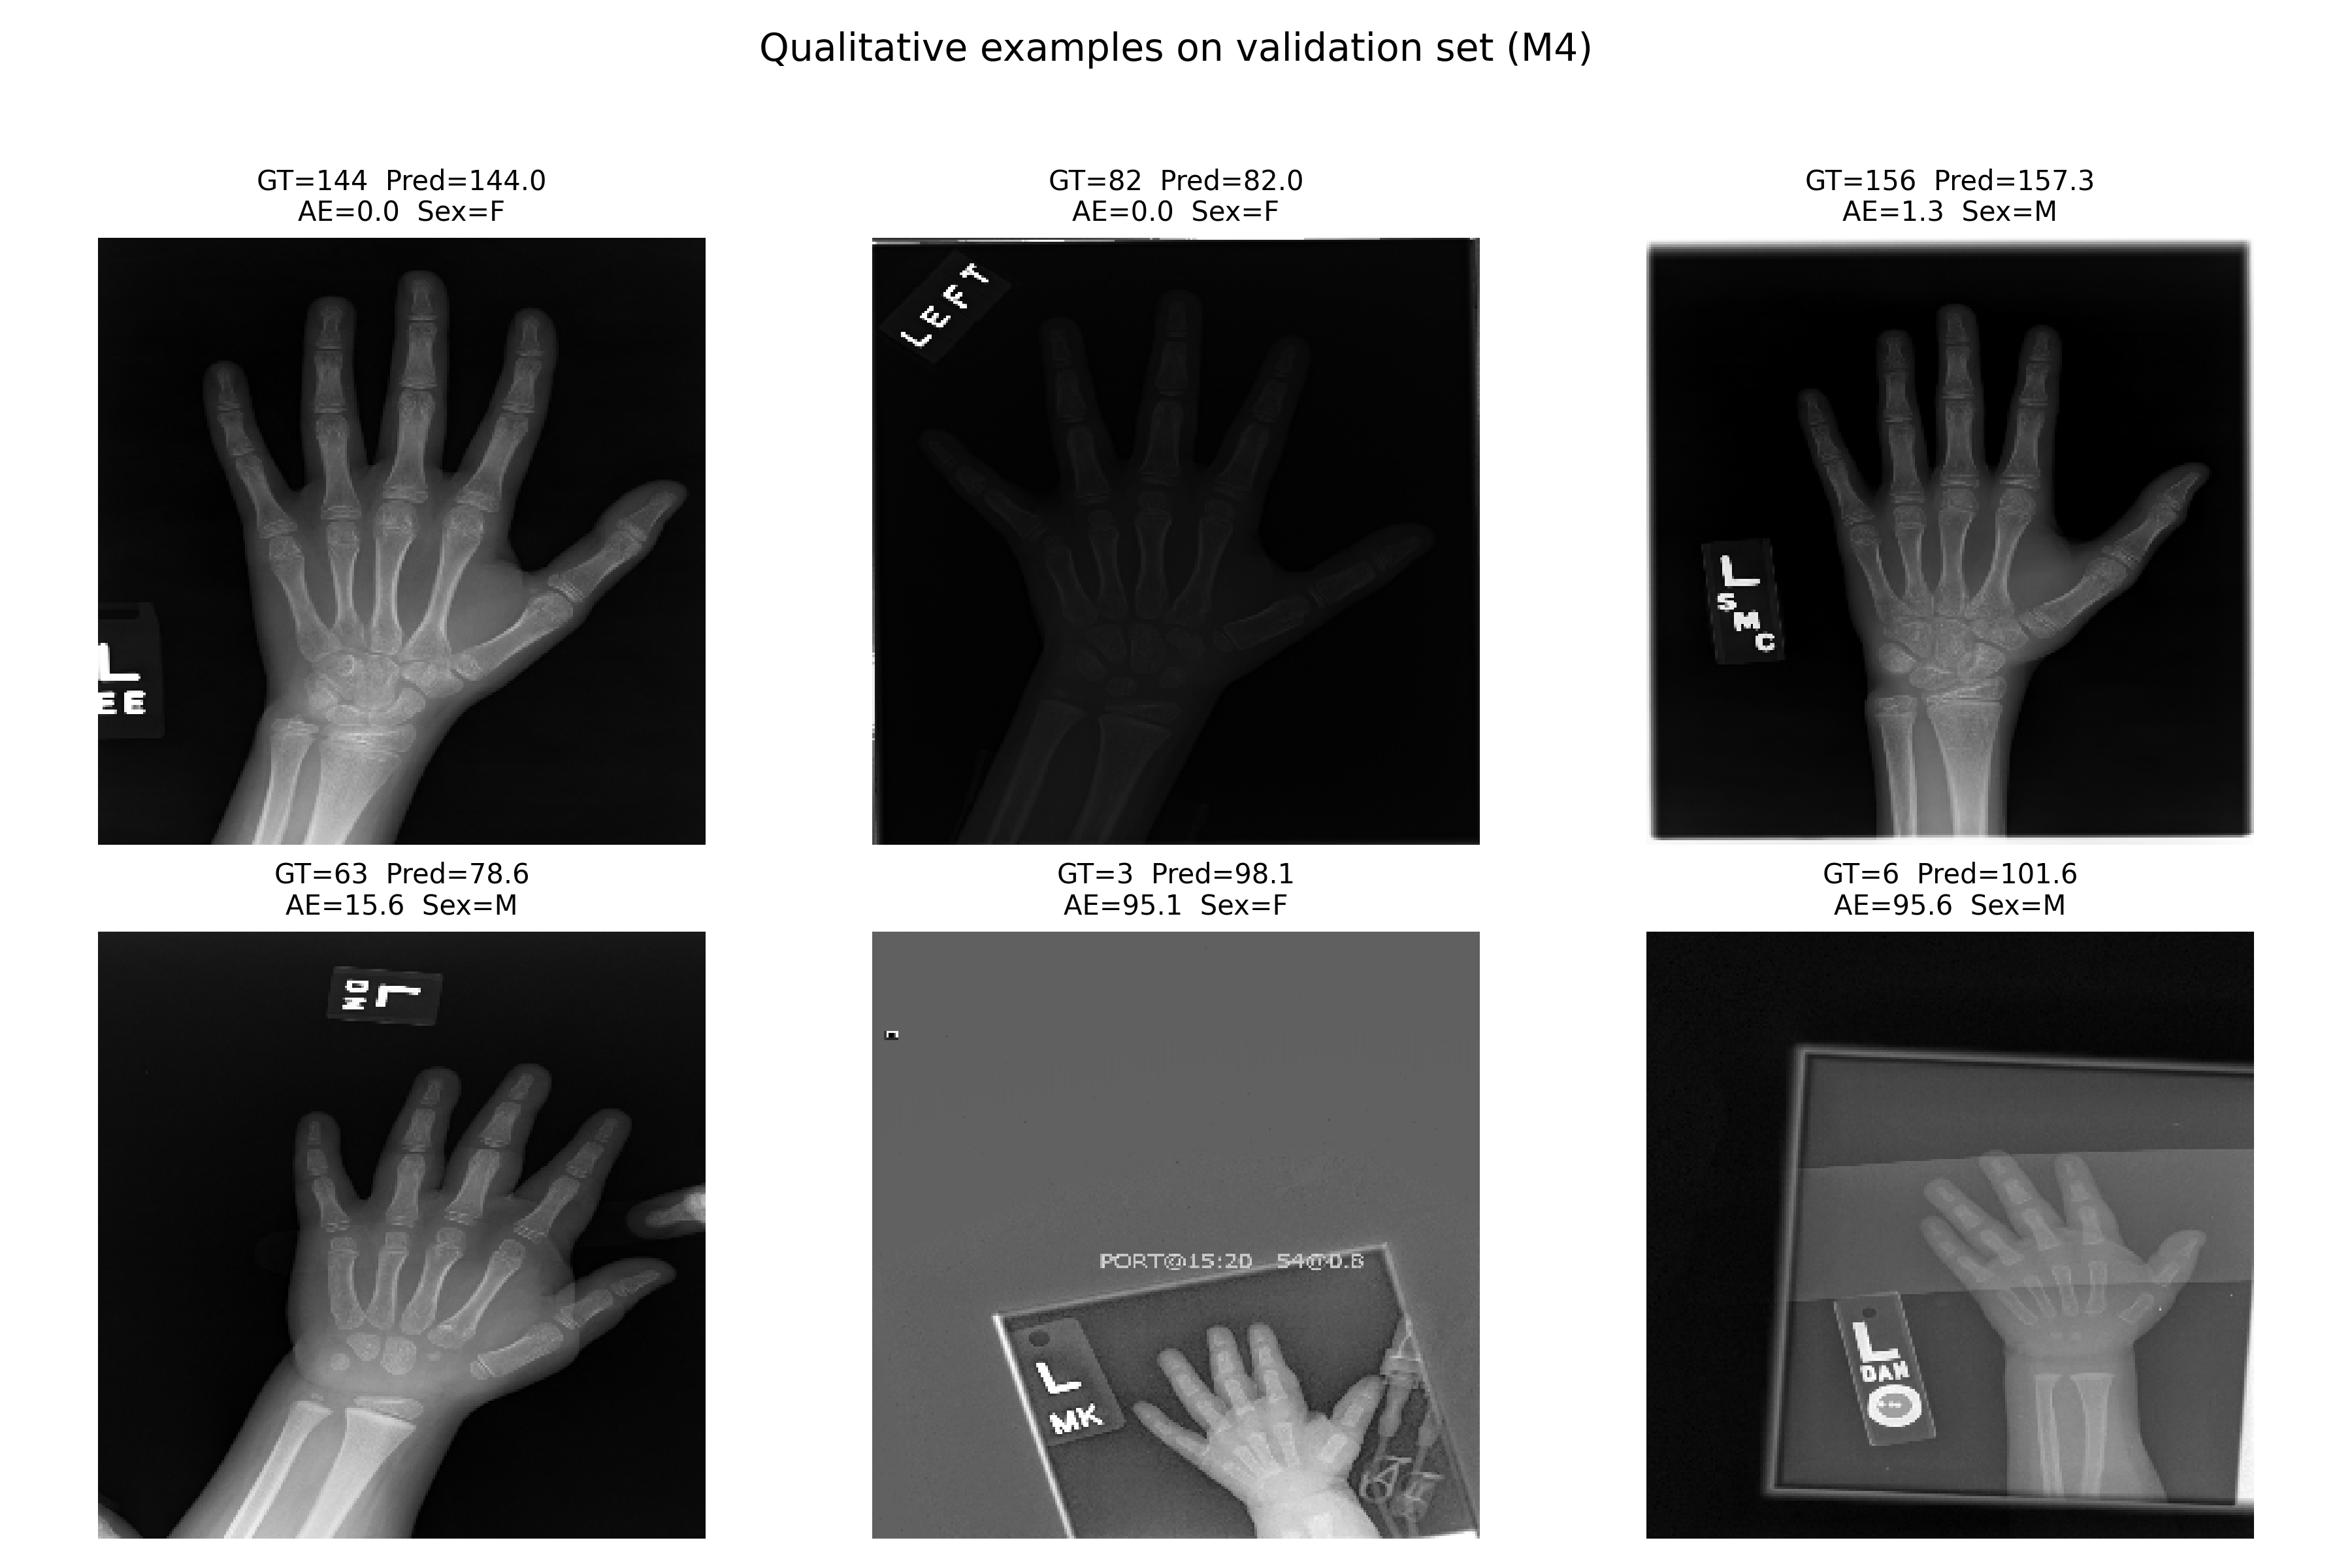

Saved: /kaggle/working/qualitative_examples.png


In [ ]:
MODEL_PATH = "/kaggle/working/m4_best.keras"
OUT_PATH   = "/kaggle/working/qualitative_examples.png"
N_SHOW     = 6

best_model = tf.keras.models.load_model(MODEL_PATH, compile=False)

IMG_SIZE = 256  

def decode_for_display(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.cast(img, tf.float32)
    img = (img - tf.reduce_min(img)) / (tf.reduce_max(img) - tf.reduce_min(img) + 1e-8)
    return img.numpy().squeeze()

def make_inputs_for_model(paths, genders, model):
    input_names = [t.name.split(":")[0] for t in model.inputs]
    use_patches = any("patches" in n for n in input_names)

    def decode_raw(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=1)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)
        return img

    imgs = tf.stack([decode_raw(p) for p in paths], axis=0)
    imgs = (imgs - tf.cast(x_mean, tf.float32)) / tf.cast(x_std, tf.float32)

    x = {}
    if use_patches:
        PATCH, STRIDE = 128, 64
        def extract_patches_single(img):
            img4 = tf.expand_dims(img, 0)
            patches = tf.image.extract_patches(
                images=img4,
                sizes=[1, PATCH, PATCH, 1],
                strides=[1, STRIDE, STRIDE, 1],
                rates=[1, 1, 1, 1],
                padding="VALID"
            )
            nH = tf.shape(patches)[1]; nW = tf.shape(patches)[2]
            P = nH * nW
            return tf.reshape(patches, [P, PATCH, PATCH, 1])

        patches = tf.stack([extract_patches_single(imgs[i]) for i in range(imgs.shape[0])], axis=0)
        x["patches"] = patches
    else:
        x["img"] = imgs

    if any("gender" in n for n in input_names):
        x["gender"] = tf.convert_to_tensor(genders.reshape(-1, 1), dtype=tf.float32)

    return x

def predict_months(model, paths, genders):
    x = make_inputs_for_model(paths, genders, model)
    y_pred_std = model.predict(x, verbose=0).reshape(-1).astype(np.float32)
    return y_pred_std * float(y_std) + float(y_mean)

paths_all = val_df["path"].values
g_all = val_df["male"].values.astype(np.float32)
y_true_all = val_df["boneage"].values.astype(np.float32)

# Predict all validation
B = 32
y_pred_all = np.zeros(len(val_df), dtype=np.float32)
for i in range(0, len(val_df), B):
    y_pred_all[i:i+B] = predict_months(best_model, paths_all[i:i+B].tolist(), g_all[i:i+B])

abs_err = np.abs(y_pred_all - y_true_all)

rng = np.random.default_rng(SEED)
idx_sorted = np.argsort(abs_err)

chosen = np.concatenate([
    idx_sorted[:2],
    rng.choice(idx_sorted[2:-2], size=2, replace=False),
    idx_sorted[-2:],
])[:N_SHOW]

plt.figure(figsize=(12, 8))

# Use a neutral title color; images are grayscale
for j, idx in enumerate(chosen):
    ax = plt.subplot(2, 3, j+1)
    img = decode_for_display(paths_all[idx])
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    gt = float(y_true_all[idx]); pr = float(y_pred_all[idx]); ae = float(abs_err[idx])
    sex = "M" if int(g_all[idx]) == 1 else "F"
    ax.set_title(f"GT={gt:.0f}  Pred={pr:.1f}\nAE={ae:.1f}  Sex={sex}", fontsize=10)

plt.suptitle("Qualitative examples on validation set (M4)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUT_PATH, dpi=300)
plt.close()

show_saved(OUT_PATH)

Saved: /kaggle/working/patch_examples_triplet_clean.png


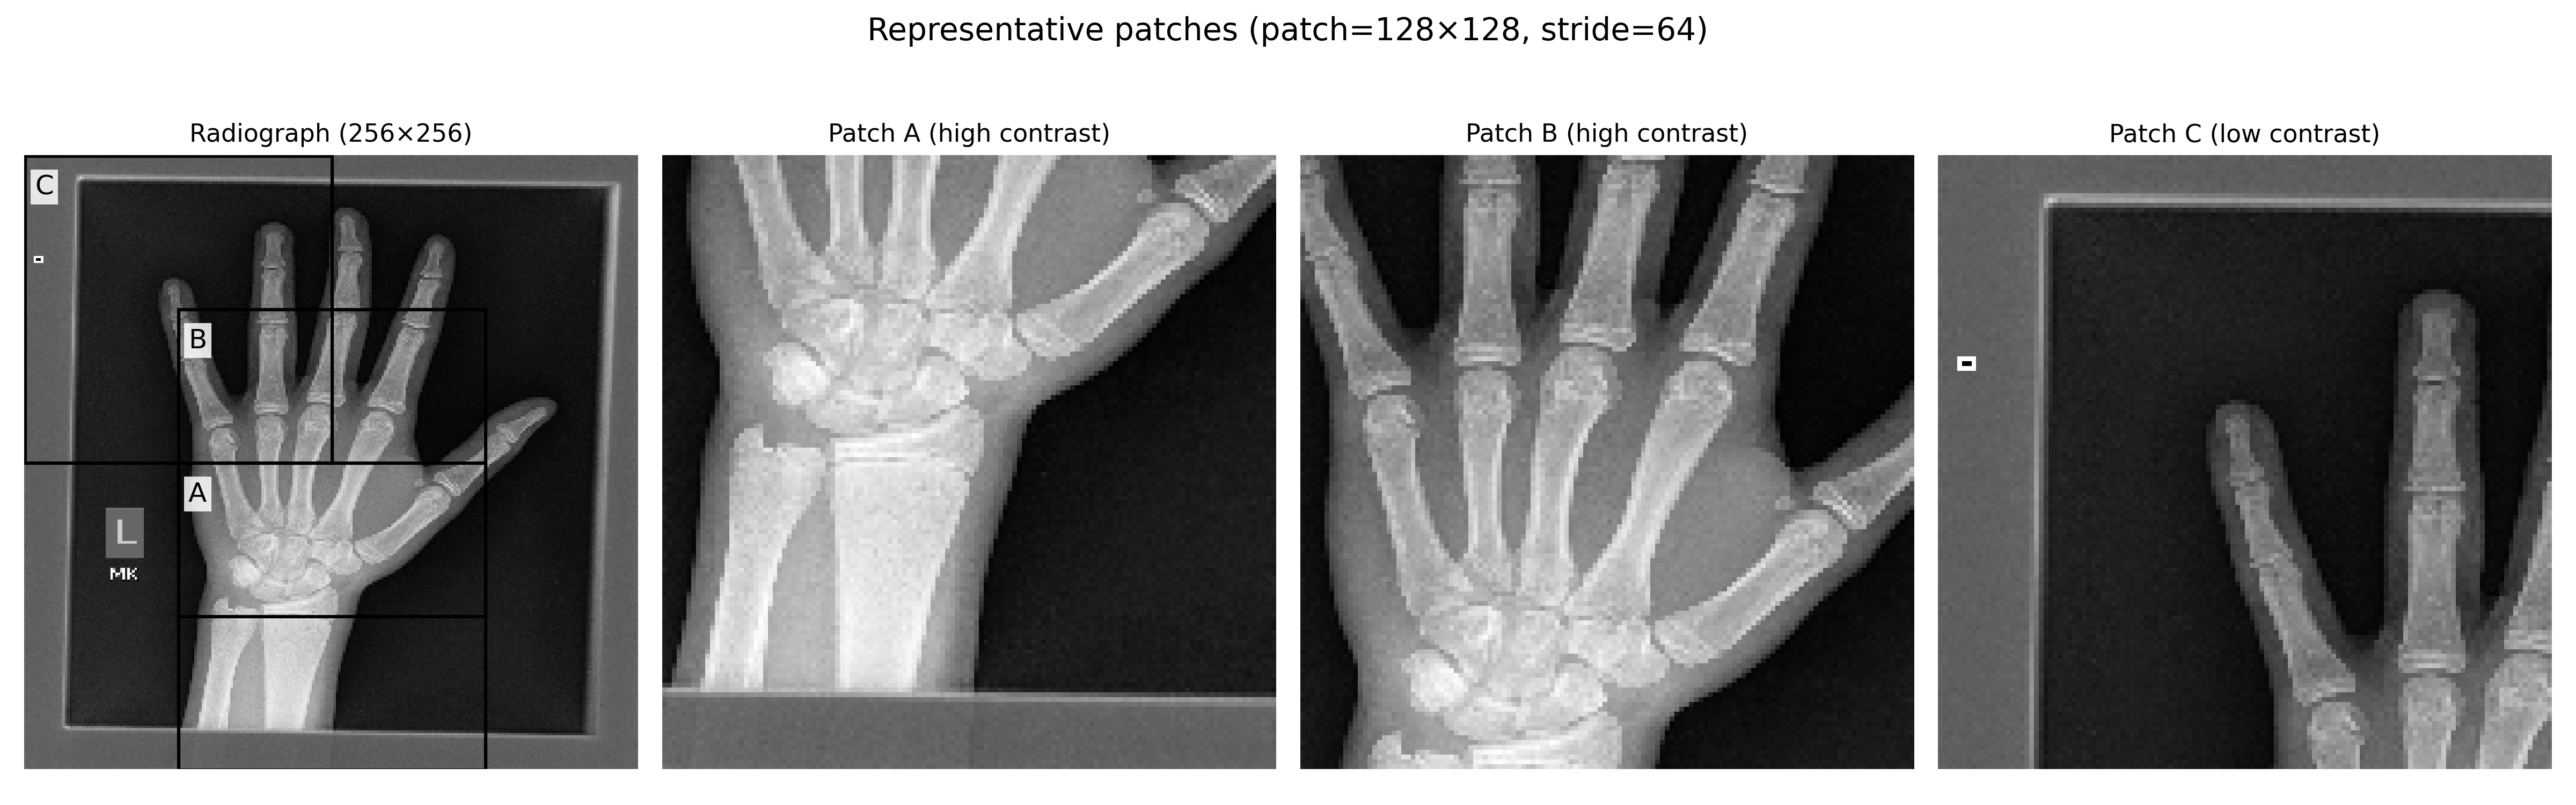

Saved: /kaggle/working/patch_examples_triplet_clean.png
Selected patch top-left coords (x,y): [(64, 128), (64, 64), (0, 0)]
Scores (std) for A,B,C: [0.27559593319892883, 0.25795209407806396, 0.175119549036026]


In [ ]:
OUT_PATH = "/kaggle/working/patch_examples_triplet_clean.png"

IMG_SIZE = 256
PATCH = 128
STRIDE = 64

IDX = 183
img_path = val_df.iloc[IDX]["path"]

def decode_for_display(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.cast(img, tf.float32)
    img = (img - tf.reduce_min(img)) / (tf.reduce_max(img) - tf.reduce_min(img) + 1e-8)
    return img.numpy().squeeze()

img = decode_for_display(img_path, IMG_SIZE)

ys = list(range(0, IMG_SIZE - PATCH + 1, STRIDE))
xs = list(range(0, IMG_SIZE - PATCH + 1, STRIDE))
grid_coords = [(x, y) for y in ys for x in xs]

def patch_score(img, x, y, patch=PATCH):
    p = img[y:y+patch, x:x+patch]
    return float(np.std(p))

scores = np.array([patch_score(img, x, y) for (x, y) in grid_coords], dtype=np.float32)
idx_sorted = np.argsort(scores)

# low-contrast 
low_idx = int(idx_sorted[0])

# two high-contrast patches
top_candidates = idx_sorted[::-1].tolist()
chosen_high = []
for idx in top_candidates:
    x, y = grid_coords[idx]
    if not chosen_high:
        chosen_high.append(idx)
    else:
        x0, y0 = grid_coords[chosen_high[0]]
        if abs(x - x0) + abs(y - y0) >= PATCH // 2:
            chosen_high.append(idx)
    if len(chosen_high) == 2:
        break
if len(chosen_high) < 2:
    chosen_high = [int(idx_sorted[-1]), int(idx_sorted[-2])]

chosen_idxs = [chosen_high[0], chosen_high[1], low_idx]
labels = ["A (high contrast)", "B (high contrast)", "C (low contrast)"]

coords = []
patches = []
for idx in chosen_idxs:
    x, y = grid_coords[idx]
    coords.append((x, y))
    patches.append(img[y:y+PATCH, x:x+PATCH])

# ---- Plot (1x4) ----
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Full image with boxes
ax0 = axes[0]
ax0.imshow(img, cmap="gray")
ax0.axis("off")
ax0.set_title("Radiograph (256×256)", fontsize=11)

for (x, y), lab in zip(coords, ["A", "B", "C"]):
    rect = mpatches.Rectangle((x, y), PATCH, PATCH, fill=False, linewidth=1.5)
    ax0.add_patch(rect)
    ax0.text(x + 4, y + 16, lab, fontsize=12,
             bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2))

# Patch crops
for i in range(3):
    ax = axes[i+1]
    ax.imshow(patches[i], cmap="gray")
    ax.axis("off")
    ax.set_title(f"Patch {labels[i]}", fontsize=11)

fig.suptitle(f"Representative patches (patch={PATCH}×{PATCH}, stride={STRIDE})", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(OUT_PATH, dpi=300)
plt.close(fig)

print("Saved:", OUT_PATH)
show_saved(OUT_PATH)

print("Selected patch top-left coords (x,y):", coords)
print("Scores (std) for A,B,C:", [float(scores[i]) for i in chosen_idxs])
